# Red Neuronal PINN-PCA para 100 transiciones
Predicción de los coeficientes de las Componentes Principales (PCA) a partir de 16 posiciones de Hammett.
La función de pérdida (Loss) es de doble componente: MSE de los pesos PCA + MSE de la reconstrucción morfológica del espectro (Physics-Informed), garantizando una adaptación perfecta a las 100 transiciones de alta fidelidad.

## 1. Imports y Configuración global del modelo

In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import time
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.spatial.distance import cosine
from scipy.integrate import trapezoid
torch.manual_seed(42)
np.random.seed(42)

In [14]:
from dataclasses import dataclass

@dataclass
class Config:
    # --- Parámetro clave del estudio PCA ---
    num_pcas:    int     = 10      # <--- ¡Cámbialo a 15 para hacer el otro script!

    # Arquitectura
    input_dim:   int     = 16
    hidden1:     int     = 128
    hidden2:     int     = 64
    hidden3:     int     = 32
    # El output_dim lo cogerá dinámicamente de num_pcas

    # Entrenamiento
    lr:          float   = 1e-3
    batch_size:  int     = 16
    epochs:      int     = 300
    test_size:   float   = 0.2

    # Loss Mixta (PINN)
    alpha:       float   = 1.0     # Peso del error en los parámetros PCA
    beta:        float   = 0     # Peso del error en la reconstrucción física

cfg = Config()
print(cfg)

Config(num_pcas=10, input_dim=16, hidden1=128, hidden2=64, hidden3=32, lr=0.001, batch_size=16, epochs=300, test_size=0.2, alpha=1.0, beta=0)


## 2. Carga de datos, Cálculo Delta S y PCA
Usamos los espectros completos y el heliceno base obtenidos en pasos anteriores.

In [15]:

print("📂 Cargando base de datos unificada de 100 transiciones...")

# 1. Rutas de los archivos (Ya no necesitamos PATH_ENV_VIEJAS)
PATH_ECD_100 = '../Bases de datos/Dataset_ECD_100R.csv' 
PATH_BASE = '../Bases de datos/6Heliceno.csv'

# 2. Carga de DataFrames
# NOTA: He puesto decimal=',' por si los números usan coma (como el 6Heliceno). 
# Si usan punto, simplemente borra ese parámetro.
df_ecd = pd.read_csv(PATH_ECD_100, sep=';', decimal=',').drop_duplicates(subset=['Molecula'])
df_base = pd.read_csv(PATH_BASE, sep=';', decimal=',')

# 3. Extraer X (Las 16 Posiciones de Hammett directamente del archivo nuevo)
pos_cols = [f'Pos_{i}' for i in range(1, 17)]
X_raw = df_ecd[pos_cols].values.astype(np.float32)

# ====================================================================
# 4. GENERACIÓN DE LOS ESPECTROS CONTINUOS (S_real y S_base)
# ====================================================================
wl_nm = np.linspace(200, 600, 100)
sigma_ev = 0.2
HC_EV_NM = 1240.0

print("⚙️ Calculando espectros continuos de 100 puntos (S_real) para el dataset...")
R_COLS = [f'R_{i}' for i in range(1, 101) if f'R_{i}' in df_ecd.columns]
NM_COLS = [f'nm_{i}' for i in range(1, 101) if f'nm_{i}' in df_ecd.columns]

R_matrix = df_ecd[R_COLS].values.astype(float)
NM_matrix = df_ecd[NM_COLS].values.astype(float)

S_real_list = []
# Bucle vectorizado molécula a molécula
for i in range(len(df_ecd)):
    r_vals = R_matrix[i]
    nm_vals = NM_matrix[i]
    spectrum_mol = np.zeros_like(wl_nm)
    
    for R, nm in zip(r_vals, nm_vals):
        if np.isnan(R) or np.isnan(nm): continue
        sigma_nm = (nm**2 / HC_EV_NM) * sigma_ev + 1e-5
        spectrum_mol += R * np.exp(-((wl_nm - nm)**2) / (2 * sigma_nm**2))
        
    S_real_list.append(spectrum_mol)

S_real = np.stack(S_real_list).astype(np.float32)

print("⚙️ Calculando espectro del heliceno base (S_base)...")
R_COLS_BASE = [f'R_{i}' for i in range(1, 101) if f'R_{i}' in df_base.columns]
NM_COLS_BASE = [f'nm_{i}' for i in range(1, 101) if f'nm_{i}' in df_base.columns]

r_base = df_base.iloc[0][R_COLS_BASE].values.astype(float)
nm_base = df_base.iloc[0][NM_COLS_BASE].values.astype(float)

S_base = np.zeros_like(wl_nm)
for R, nm in zip(r_base, nm_base):
    if np.isnan(R) or np.isnan(nm): continue
    sigma_nm = (nm**2 / HC_EV_NM) * sigma_ev + 1e-5
    S_base += R * np.exp(-((wl_nm - nm)**2) / (2 * sigma_nm**2))

S_base = S_base.astype(np.float32)

# ====================================================================
# 5. CÁLCULO DEL RESIDUAL (Delta S)
# ====================================================================
Delta_S = S_real - S_base

print(f'\n✅ Datos cargados y procesados con éxito (Sin cruces innecesarios).')
print(f'   - Moléculas procesadas: {X_raw.shape[0]}')
print(f'   - X_raw (Hammett 16 pos):  {X_raw.shape}')
print(f'   - S_real (100 puntos):     {S_real.shape}')
print(f'   - Delta_S (100 puntos):    {Delta_S.shape}')

📂 Cargando base de datos unificada de 100 transiciones...
⚙️ Calculando espectros continuos de 100 puntos (S_real) para el dataset...
⚙️ Calculando espectro del heliceno base (S_base)...

✅ Datos cargados y procesados con éxito (Sin cruces innecesarios).
   - Moléculas procesadas: 12407
   - X_raw (Hammett 16 pos):  (12407, 16)
   - S_real (100 puntos):     (12407, 100)
   - Delta_S (100 puntos):    (12407, 100)


## 3. Split de Datos, Normalización y PCA (Sin Leakage)
Para garantizar el rigor del modelo, primero separamos los datos en Train y Test. Después, el `StandardScaler` y el algoritmo `PCA` se ajustan (`fit`) **exclusivamente sobre el conjunto de entrenamiento**. Finalmente, aplicamos esa transformación (`transform`) al test para no contaminar las métricas de evaluación.

In [16]:
# ── 1. Split train/test ANTES de cualquier transformación
idx = np.arange(len(X_raw))
idx_tr, idx_te = train_test_split(idx, test_size=cfg.test_size, random_state=42)

# ── 2. Normalizar Entradas X (Fit SOLO en Train)
scaler_X = StandardScaler()
X_tr_norm = scaler_X.fit_transform(X_raw[idx_tr])
X_te_norm = scaler_X.transform(X_raw[idx_te])

# ── 3. Normalizar Intensidades (I_SCALE calculado SOLO en Train)
I_SCALE = float(np.max(np.abs(Delta_S[idx_tr])))
Delta_S_tr_norm = Delta_S[idx_tr] / I_SCALE
Delta_S_te_norm = Delta_S[idx_te] / I_SCALE

# ── 4. Ajustar PCA (Fit SOLO en Train)
print(f"⚙️ Ajustando PCA para {cfg.num_pcas} componentes sobre el Train set...")
pca_final = PCA(n_components=cfg.num_pcas, random_state=42)
pesos_tr_norm = pca_final.fit_transform(Delta_S_tr_norm)
pesos_te_norm = pca_final.transform(Delta_S_te_norm)

componentes_pca = pca_final.components_  # Matriz (num_pcas, 100)

# Imprimimos la varianza explicada para justificar el hiperparámetro (Problema 4)
print(f"✅ Varianza explicada por {cfg.num_pcas} PCAs: {np.sum(pca_final.explained_variance_ratio_) * 100:.2f}%")

# ── 5. Creación de Tensores y DataLoaders
def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

X_tr,  X_te  = to_t(X_tr_norm),       to_t(X_te_norm)
Yw_tr, Yw_te = to_t(pesos_tr_norm),   to_t(pesos_te_norm)
Ys_tr, Ys_te = to_t(S_real[idx_tr]),  to_t(S_real[idx_te])

train_loader = DataLoader(
    TensorDataset(X_tr, Yw_tr, Ys_tr),
    batch_size=cfg.batch_size, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(X_te, Yw_te, Ys_te),
    batch_size=cfg.batch_size, shuffle=False
)

print(f'\n📊 Resumen de tensores listos para PyTorch:')
print(f'Train: {len(idx_tr)} muestras | Test: {len(idx_te)} muestras')
print(f"X_tr media = {X_tr_norm.mean():.4f} | X_tr std = {X_tr_norm.std():.4f}")
print(f"I_SCALE = {I_SCALE:.4f}")

⚙️ Ajustando PCA para 10 componentes sobre el Train set...
✅ Varianza explicada por 10 PCAs: 97.93%

📊 Resumen de tensores listos para PyTorch:
Train: 9925 muestras | Test: 2482 muestras
X_tr media = 0.0000 | X_tr std = 1.0000
I_SCALE = 1895.3535


## 5. Arquitectura de la red neuronal
Aprovechamos el truco de la simetría molecular (C2 del heliceno) invirtiendo el tensor de entrada y promediando.

In [17]:
class HelicenoPCANet(nn.Module):
    """
    Red neuronal profunda para predecir los pesos PCA del espectro.
    """
    def __init__(self, cfg: Config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.input_dim, cfg.hidden1),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(cfg.hidden1, cfg.hidden2),
            nn.ReLU(),
            nn.Linear(cfg.hidden2, cfg.hidden3), 
            nn.ReLU(),
            nn.Linear(cfg.hidden3, cfg.num_pcas), # Salida dinámica según config
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # El truco genial de la simetría C2 se mantiene intacto
        x_flip = torch.flip(x, dims=[1])
        return 0.5 * (self.net(x) + self.net(x_flip))

model = HelicenoPCANet(cfg)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nParámetros entrenables: {n_params}')

HelicenoPCANet(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=10, bias=True)
  )
)

Parámetros entrenables: 12842


## Definición de métricas que usaremos

In [18]:

def calcular_metricas_globales(Y_true, Y_pred, wl_nm):
    """
    Calcula y devuelve las métricas de evaluación espectral.
    Y_true, Y_pred: Arrays de NumPy con los espectros reales y predichos (N_muestras, 100)
    wl_nm: Eje X de longitudes de onda para calcular la integral (IAD).
    """
    mae = mean_absolute_error(Y_true.flatten(), Y_pred.flatten())
    mse = mean_squared_error(Y_true.flatten(), Y_pred.flatten())
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_true.flatten(), Y_pred.flatten())
    
    # Similitud del Coseno (promedio por molécula)
    cosenos = []
    for i in range(len(Y_true)):
        if np.all(Y_true[i] == 0) or np.all(Y_pred[i] == 0):
            cosenos.append(0.0)
        else:
            cosenos.append(1.0 - cosine(Y_true[i], Y_pred[i]))
    coseno_medio = np.mean(cosenos)
    
    # Integral de Área de Discrepancia (IAD)
    iad_array = trapezoid(np.abs(Y_true - Y_pred), x=wl_nm, axis=1)
    iad_medio = np.mean(iad_array)
    
    return mae, mse, rmse, r2, coseno_medio, iad_medio

print("Herramientas de cálculo de métricas definidas correctamente.")

Herramientas de cálculo de métricas definidas correctamente.


## 6. Construcción del espectro y función de pérdida

In [19]:
# ── Tensores constantes para la reconstrucción
S_base_t = torch.tensor(S_base, dtype=torch.float32)
pca_comps_t = torch.tensor(componentes_pca, dtype=torch.float32)
I_SCALE_t = torch.tensor(I_SCALE, dtype=torch.float32)

def build_spectrum_pca(pred_weights_norm: torch.Tensor) -> torch.Tensor:
    """
    Reconstruye el espectro físico final diferenciable a través de multiplicación matricial.
    """
    # 1. Multiplicamos pesos predichos por las componentes
    pred_Delta_S_norm = torch.matmul(pred_weights_norm, pca_comps_t)
    
    # 2. Desnormalizamos
    pred_Delta_S = pred_Delta_S_norm * I_SCALE_t
    
    # 3. Sumamos el heliceno base
    pred_spectra = pred_Delta_S + S_base_t
    
    return pred_spectra

mse = nn.MSELoss()
def physics_loss_pca(pred_weights_norm: torch.Tensor,
                     target_weights_norm: torch.Tensor,
                     target_spec_real: torch.Tensor) -> tuple:
    """
    Loss total = alpha * MSE(pesos) + beta * MSE(espectro reconstruido normalizado).
    """


    # 1. Parameter Loss (Calculado en espacio normalizado -> Valores bajitos)
    loss_weights  = mse(pred_weights_norm, target_weights_norm)

    # 2. Reconstrucción física (Esto sale en escala real)
    pred_spec     = build_spectrum_pca(pred_weights_norm)
    
    # ---> 3. LA SOLUCIÓN: NORMALIZACIÓN DE LA LOSS FÍSICA <---
    # Dividimos ambos espectros por I_SCALE_t ANTES de hacer el MSE.
    # Así, loss_spectra vuelve a ser un número pequeño (del mismo orden que loss_weights).
    loss_spectra  = mse(pred_spec / I_SCALE_t, target_spec_real / I_SCALE_t)

    # 4. Loss Total Equilibrada
    loss_total    = cfg.alpha * loss_weights + cfg.beta * loss_spectra
    
    return loss_total, loss_weights, loss_spectra

## 7. Entrenamiento

In [20]:
import os

optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=1e-5)

history = {'total': [], 'params': [], 'spectra': [],
           'val_total': [], 'val_params': [], 'val_spectra': []}

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15
)

paciencia_max = 60 
paciencia_actual = 0
mejor_val_loss = float('inf')

print(f'Entrenando máximo {cfg.epochs} épocas con Early Stopping...')
for epoch in range(1, cfg.epochs + 1):

    # ── Train
    model.train()
    ep_total, ep_params, ep_spectra = 0.0, 0.0, 0.0
    for bX, bYw, bYs in train_loader:
        optimizer.zero_grad()
        pred  = model(bX)
        loss, lp, ls = physics_loss_pca(pred, bYw, bYs)
        loss.backward()
        optimizer.step()
        
        ep_total   += loss.item()
        ep_params  += lp.item()
        ep_spectra += ls.item()

    n_tr = len(train_loader)
    history['total'].append(ep_total / n_tr)
    history['params'].append(ep_params / n_tr)
    history['spectra'].append(ep_spectra / n_tr)

    # ── Validation
    model.eval()
    vt, vp, vs = 0.0, 0.0, 0.0
    with torch.no_grad():
        for bX, bYw, bYs in test_loader:
            pred = model(bX)
            loss, lp, ls = physics_loss_pca(pred, bYw, bYs)
            vt += loss.item()
            vp += lp.item()
            vs += ls.item()
            
    n_te = len(test_loader)
    current_val_loss = vt / n_te
    history['val_total'].append(current_val_loss)
    history['val_params'].append(vp / n_te)
    history['val_spectra'].append(vs / n_te)

    scheduler.step(current_val_loss)
    
    # ── Early Stopping y Guardado del Modelo
    if current_val_loss < mejor_val_loss:
        mejor_val_loss = current_val_loss
        paciencia_actual = 0
        torch.save(model.state_dict(), f'mejor_modelo_pinn_pca_{cfg.num_pcas}.pt')
    else:
        paciencia_actual += 1

    if epoch % 25 == 0:
        print(f'Época {epoch:4d} | '
              f'Train total={history["total"][-1]:.4f} '
              f'(params={history["params"][-1]:.4f}, spec={history["spectra"][-1]:.4f}) | '
              f'Val total={history["val_total"][-1]:.4f} | '
              f'Paciencia: {paciencia_actual}/{paciencia_max}')

    if paciencia_actual >= paciencia_max:
        print(f'\n[!] Early Stopping activado en la época {epoch}.')
        break

print('\n¡Entrenamiento completado!')
model.load_state_dict(torch.load(f'mejor_modelo_pinn_pca_{cfg.num_pcas}.pt'))
print(f"-> Se han cargado los pesos óptimos. Mejor Val Loss (Total): {mejor_val_loss:.4f}")

Entrenando máximo 300 épocas con Early Stopping...
Época   25 | Train total=0.0154 (params=0.0154, spec=0.0079) | Val total=0.0162 | Paciencia: 1/60
Época   50 | Train total=0.0142 (params=0.0142, spec=0.0078) | Val total=0.0158 | Paciencia: 5/60
Época   75 | Train total=0.0138 (params=0.0138, spec=0.0077) | Val total=0.0159 | Paciencia: 13/60
Época  100 | Train total=0.0128 (params=0.0128, spec=0.0077) | Val total=0.0158 | Paciencia: 8/60
Época  125 | Train total=0.0122 (params=0.0122, spec=0.0076) | Val total=0.0154 | Paciencia: 6/60
Época  150 | Train total=0.0119 (params=0.0119, spec=0.0075) | Val total=0.0152 | Paciencia: 0/60
Época  175 | Train total=0.0118 (params=0.0118, spec=0.0076) | Val total=0.0153 | Paciencia: 9/60
Época  200 | Train total=0.0116 (params=0.0116, spec=0.0075) | Val total=0.0153 | Paciencia: 34/60
Época  225 | Train total=0.0116 (params=0.0116, spec=0.0075) | Val total=0.0152 | Paciencia: 59/60

[!] Early Stopping activado en la época 226.

¡Entrenamiento co

## 8. Curvas de pérdida
Se combinan las pérdidas de los valores de los parámetros y los del espectro reconstruido.

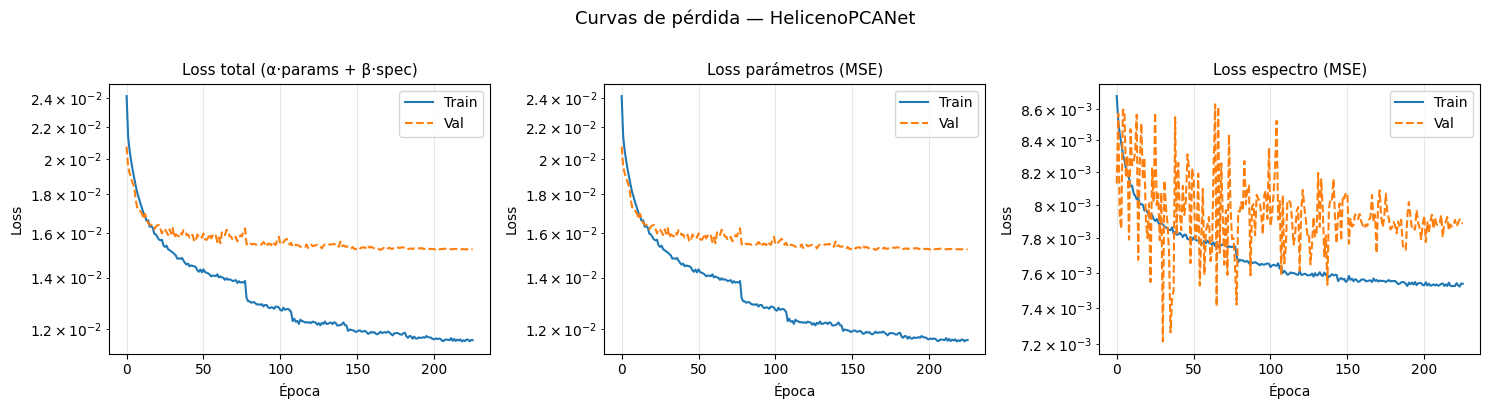

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('total', 'Loss total (α·params + β·spec)'),
         ('params', 'Loss parámetros (MSE)'),
         ('spectra', 'Loss espectro (MSE)')]

for ax, (key, title) in zip(axes, pairs):
    ax.plot(history[key],     label='Train', linewidth=1.5)
    ax.plot(history[f'val_{key}'], label='Val',   linewidth=1.5, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de pérdida — HelicenoPCANet', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Métricas sobre el conjunto test
Se calculan en **escala real** y **escala normalizada** para poder comparar correctamente.
Se calculan MAE, MSE, RMSE, R2, nMAE, nMSE, MAPE(%) y MaxErr.

In [22]:
print("📊 INFERENCIA Y EVALUACIÓN FINAL EN EL CONJUNTO DE TEST...")

# 1. Inferencia
model.eval()
with torch.no_grad():
    # Predecimos y reconstruimos
    pred_weights_norm = model(X_te)
    pred_spectra_tensor = build_spectrum_pca(pred_weights_norm)

# 2. Convertimos a NumPy
Y_pred = pred_spectra_tensor.numpy()
Y_true = Ys_te.numpy()

# 3. Llamamos a nuestra función de métricas definida anteriormente
mae, mse, rmse, r2, coseno_medio, iad_medio = calcular_metricas_globales(Y_true, Y_pred, wl_nm)

# 4. Imprimir y guardar resultados
print("=" * 50)
print(f" RESULTADOS FINALES PINN-PCA ({cfg.num_pcas} Componentes)")
print("=" * 50)
print(f"  MAE:    {mae:.4f}")
print(f"  MSE:    {mse:.4f}")
print(f"  RMSE:   {rmse:.4f}")
print(f"  R²:     {r2:.4f}")
print(f"  Coseno: {coseno_medio:.4f}")
print(f"  IAD:    {iad_medio:.4f}")
print("=" * 50)

# Guardado automático para no perder los datos al cambiar entre 10 y 15 PCAs
with open(f"Resultados_Test_PCA_{cfg.num_pcas}.txt", "w") as f:
    f.write(f"N_PCA: {cfg.num_pcas}\nMAE: {mae}\nMSE: {mse}\nRMSE: {rmse}\nR2: {r2}\nCoseno: {coseno_medio}\nIAD: {iad_medio}\n")
print(f"✅ Resultados guardados en 'Resultados_Test_PCA_{cfg.num_pcas}.txt'")

📊 INFERENCIA Y EVALUACIÓN FINAL EN EL CONJUNTO DE TEST...
 RESULTADOS FINALES PINN-PCA (10 Componentes)
  MAE:    104.6044
  MSE:    28440.9844
  RMSE:   168.6446
  R²:     -0.0027
  Coseno: 0.6924
  IAD:    42022.5391
✅ Resultados guardados en 'Resultados_Test_PCA_10.txt'


## 11. Visualización: 4 ejemplos aleatorios del test

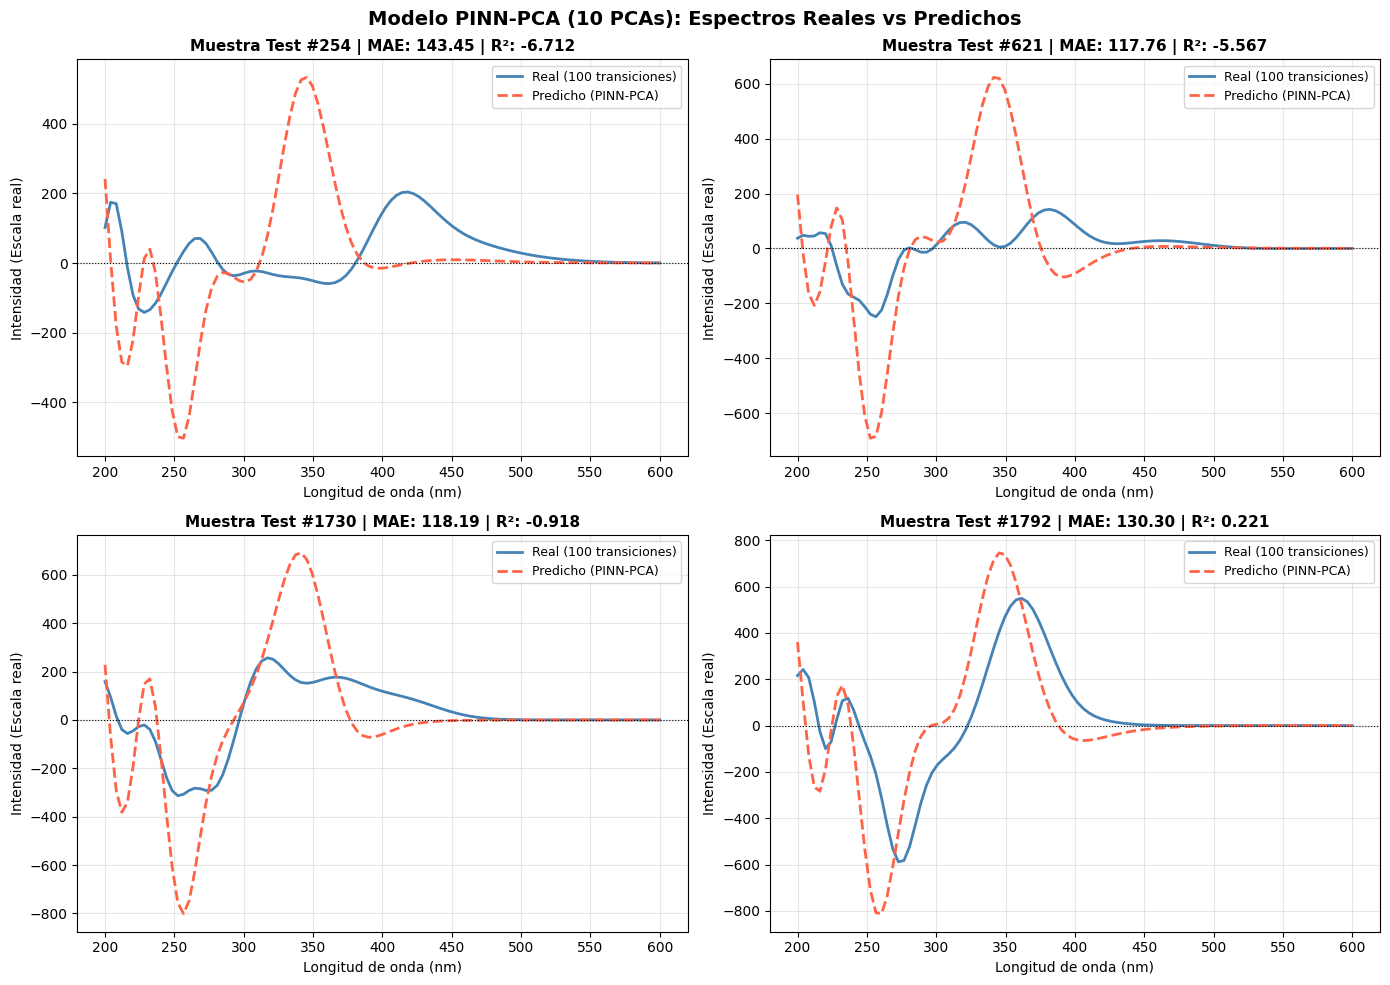

In [23]:
# ====================================================================
# --- VISUALIZAR 4 MUESTRAS DEL CONJUNTO DE TEST (MODELO PCA) ---
# ====================================================================
np.random.seed(42) 
# Elegimos 4 índices al azar del conjunto de test
indices_muestra = np.random.choice(len(Y_pred), size=4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, i in zip(axes, indices_muestra):
    # Espectros en escala real
    ax.plot(wl_nm, Y_true[i],  label='Real (100 transiciones)', linewidth=2, color='steelblue')
    ax.plot(wl_nm, Y_pred[i],  label='Predicho (PINN-PCA)', linewidth=2, color='tomato', linestyle='--')

    # Calcular métricas locales para el título
    mae_i = mean_absolute_error(Y_true[i], Y_pred[i])
    r2_i  = r2_score(Y_true[i], Y_pred[i])
    
    ax.set_title(f'Muestra Test #{i} | MAE: {mae_i:.2f} | R²: {r2_i:.3f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Longitud de onda (nm)')
    ax.set_ylabel('Intensidad (Escala real)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='dotted')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Modelo PINN-PCA ({cfg.num_pcas} PCAs): Espectros Reales vs Predichos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Guardar modelo y parámetros de normalización

In [24]:
# ====================================================================
# --- GUARDADO COMPLETO DEL MODELO PARA INFERENCIA FUTURA ---
# ====================================================================
nombre_archivo = f'modelo_pinn_pca_{cfg.num_pcas}_completo.pt'

torch.save({
    'model_state':    model.state_dict(),
    'config':         cfg,
    'I_SCALE':        I_SCALE,
    'S_base':         S_base,             # Vital para sumar la base
    'pca_components': componentes_pca,    # Vital para multiplicar por los pesos
    'wl_nm':          wl_nm,
    'scaler_X_mean':  scaler_X.mean_,     # Para normalizar las entradas nuevas
    'scaler_X_scale': scaler_X.scale_
}, nombre_archivo)

print(f'✅ Modelo PCA y todos sus hiperparámetros guardados en {nombre_archivo}')

✅ Modelo PCA y todos sus hiperparámetros guardados en modelo_pinn_pca_10_completo.pt
